In [34]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from keras.optimizers import Adam

In [35]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [36]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

In [37]:
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(8, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(pool_size=2),

    Conv2D(12, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(pool_size=2),

    Conv2D(16, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


In [38]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.7847 - loss: 0.7220 - val_accuracy: 0.9697 - val_loss: 0.1037
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9693 - loss: 0.0962 - val_accuracy: 0.9768 - val_loss: 0.0729
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9795 - loss: 0.0652 - val_accuracy: 0.9848 - val_loss: 0.0514
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9836 - loss: 0.0514 - val_accuracy: 0.9842 - val_loss: 0.0517
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9857 - loss: 0.0460 - val_accuracy: 0.9855 - val_loss: 0.0500


In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 12)     │           876 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 16)       │         1,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,652 (264.27 KB)

 Trainable params: 22,550 (88.09 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 45,102 (176.18 KB)

In [41]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest accuracy: {100*test_acc:.4f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9817 - loss: 0.0530

Test accuracy: 98.5100%


In [42]:

preds = model.predict(X_test)
predicted_classes = np.argmax(preds, axis=1)

print(predicted_classes)
print(y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]


In [43]:
import matplotlib.pyplot as plt
def RGB_image_predict(image):
  image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

  image = cv2.resize(image, (28, 28))
  plt.imshow(image)

  image = image.reshape(-1, 28, 28, 1).astype('float64')
  image /= 255.0
  preds = model.predict(image)
  ans = np.argmax(preds, axis=1)
  plt.title(f"prediction: {ans}")
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


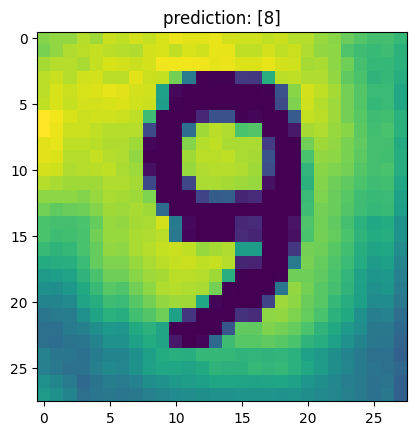

In [44]:

image_to_predict = cv2.imread(r'/content/drive/MyDrive/EMOTISENCE/file_00000000285861fdb9bb56f6efd636c5.png')
RGB_image_predict(image_to_predict)

